# BRF‑based Envelope/Order Analysis
This notebook replicates the classic SK → band‑pass → Hilbert envelope workflow, but replaces the analogue‐style filter with a **bank of resonator‑neurons** (`BRFCell`).  Every neuron is pre‑tuned to an order of interest, so we can observe
*whether its spike‑rate spectrum exhibits the expected fault lines.*

Feel free to tweak the order list, resonance damping ( `b_offset` ) or the input signal.

In [1]:
import numpy as np, pandas as pd, scipy.signal as sig, matplotlib.pyplot as plt
from pathlib import Path
import torch, torch.nn as nn

# ---- your BRF implementation ----
from brf_snn.modules import BRFCell  # <- make sure brf_snn is importable
from brf_lightning.data.bearing.utils import load_vibration_data

## 1. Choose & load one trace

In [3]:
DATA_DIR = Path('data/bearing_thl_v1')
fp = sorted(DATA_DIR.glob('*.csv'))[1]  # <-- pick first for demo
df, fs = load_vibration_data(fp)
x_raw = df['sensor_bearing'].values.astype(np.float32)
print(fp.name, fs)

fAII20.csv 8192.0


## 2. Convert to order‑domain ( one revolution = 256 samples → 1 rev vector )

In [4]:
samples_per_rev = 256
speed_hz = float(fp.stem[-2:])     # crude – '...30' -> 30 Hz
rev_period = 1/speed_hz
dt         = 1/fs
# --- resample each rev to 256 samples ---
n_total = x_raw.size
n_rev   = int(np.floor(rev_period*fs))
n_revs  = n_total // n_rev

x_revs = x_raw[:n_revs*n_rev].reshape(n_revs, n_rev)

# interpolate each revolution onto 256 points
t_src   = np.linspace(0, 1, n_rev, endpoint=False)
t_tgt   = np.linspace(0, 1, samples_per_rev, endpoint=False)
x_ords  = np.stack([np.interp(t_tgt, t_src, seg) for seg in x_revs])  # (R,256)
x_ords  = x_ords.astype(np.float32)

## 3. Build a fixed BRF neuron bank
We set $\omega$ to multiples of 2π*order / *samples_per_rev* so that each neuron
resonates at a specific order.

In [9]:
# --- helper to build a CRISPER neuron bank ----------------------------------
def make_brf_bank(orders,
                  base_speed_hz,
                  amp_scale=1.0,
                  q_target=30,          #   • higher ⇒ narrower BW
                  thr_rel=0.9,          #   • threshold 0…1 relative to steady state
                  dt=1/fs,
                  gamma=0.9):
    ωs   = 2*np.pi*base_speed_hz*np.asarray(orders)        # rad/s
    bcs  = -(ωs / q_target)                                #   bc  < 0  for damped osc
    ϑ0   = amp_scale*np.ones_like(ωs)*thr_rel              #   per-neuron thresholds
    # we keep refractory/offset arrays so we can vectorise the step
    state = dict(u=np.zeros(ωs.shape,complex),
                 q=np.zeros_like(ωs),
                 ω=ωs,
                 bc=bcs,
                 θ=ϑ0,
                 γ=gamma)
    return state

In [10]:
# --- simulate through previously resampled signal ---------------------------
def brf_forward(state, x):
    N, M = len(x), len(state['ω'])
    spikes = np.zeros((N, M), dtype=bool)
    u, q = state['u'], state['q']
    bc, ω, θ, γ = state['bc'], state['ω'], state['θ'], state['γ']
    for n,xn in enumerate(x):
        # Euler step of BRF membrane  (complex!)
        u = u + dt*((bc + 1j*ω)*u + xn)
        z = (u.real > θ)             # spike boolean
        q = γ*q + z                  # refractory
        u[z] = 0                     # HARD reset -> keeps phase
        spikes[n] = z
    state['u'], state['q'] = u, q
    return spikes


In [ ]:
orders = np.array([1.0, 3.0, 4.0, 6.0])   # <— edit to the lines you expect
layer_size   = len(orders)
omega_rad    = 2*np.pi*orders / samples_per_rev   # rad/sample
dt_sample    = 1.0  # because we work in ‘sample ‑ index’ units already

cell = BRFCell(
    input_size = 1,
    layer_size = layer_size,
    bias=False,
    adaptive_omega=False,
    adaptive_b_offset=False,
    omega=0.0,              # will overwrite below
    b_offset=0.3,
    dt=dt_sample,
)
with torch.no_grad():
    cell.omega[:] = torch.tensor(omega_rad, dtype=torch.float32)

def run_brf_batch(x_batch):
    """x_batch: (R, 256) float32 -> spike counts per rev (R, layer)"""
    T = x_batch.shape[1]
    z = torch.zeros(x_batch.shape[0], layer_size)
    state = tuple(torch.zeros(x_batch.shape[0], layer_size) for _ in range(4))
    for t in range(T):
        inp = torch.from_numpy(x_batch[:, t:t+1])  # (R,1)
        state = cell(inp, state)
        z += state[0]             # accumulate spikes
    return z.detach().numpy()

spike_counts = run_brf_batch(x_ords)

## 4. FFT of spike‑rates

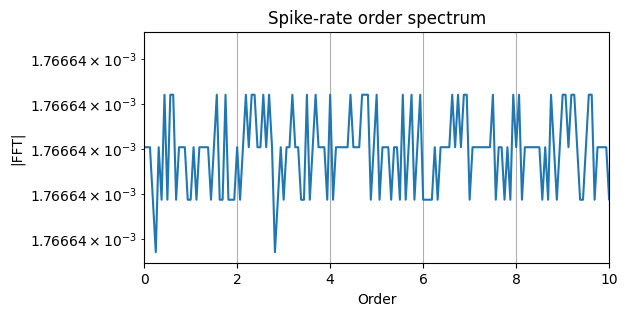

In [7]:
spec = np.fft.rfft(spike_counts.mean(0), n=4096)
orders_fft = np.fft.rfftfreq(4096, d=1/samples_per_rev)
plt.figure(figsize=(6,3))
plt.semilogy(orders_fft, np.abs(spec))
plt.xlim(0, 10)
plt.xlabel('Order'); plt.ylabel('|FFT|')
plt.title('Spike‑rate order spectrum'); plt.grid(':');

## 5. Compare with classical envelope spectrum

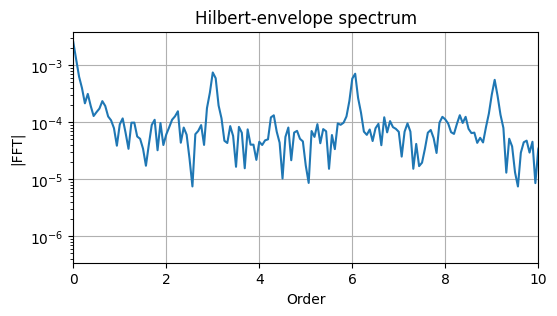

In [8]:
env = np.abs(sig.hilbert(x_ords.reshape(-1)))
spec_env = np.fft.rfft(env * np.hanning(env.size), n=4096)
plt.figure(figsize=(6,3))
plt.semilogy(orders_fft, np.abs(spec_env))
plt.xlim(0, 10); plt.xlabel('Order'); plt.ylabel('|FFT|');
plt.title('Hilbert‑envelope spectrum'); plt.grid(':')